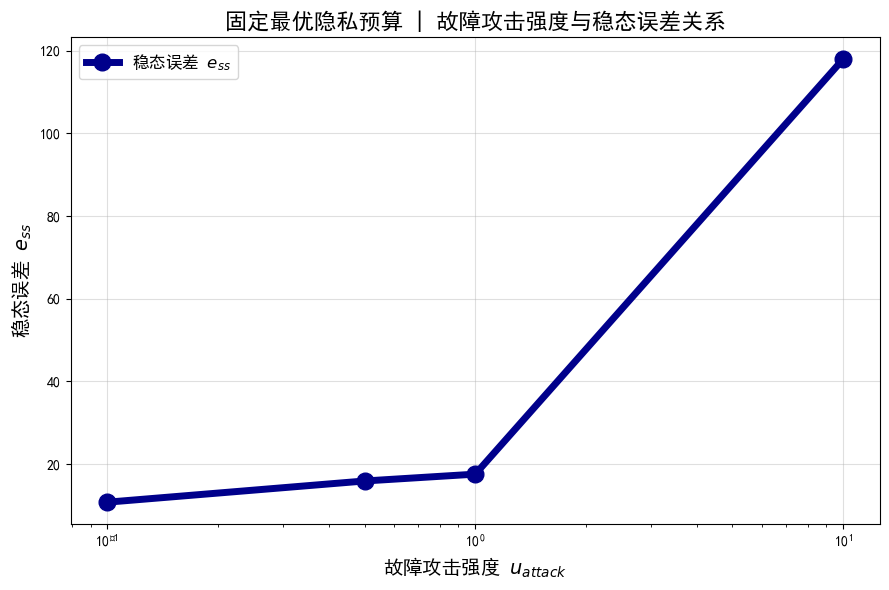

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

SEED = 93
np.random.seed(SEED)

init_params = {
    'N': 10,
    'd': 2,
    'gamma': 0.05,
    'delta': 0.05,
    'b': 1,
    'e_R': 0.5,
    'eps_list': [0.1, 0.5, 1, 10],
    'B': 4,
    'total_step': 100,
    's_i': 0.01,
    'formation_radius': 5,
    'init_pos_path': './data/initial_position.json',
    'faulty_agent_idx':0,
    'uattack_list':[0.1,0.5,1,10]
}

with open('./data/initial_position.json', 'r') as fp:
    initial_data = json.load(fp)
    initial_position = initial_data.get('initial_positions')

def init_system():
    position = np.array(initial_position).flatten()
    N, d, radius = init_params['N'], init_params['d'], init_params['formation_radius']
    p = []
    for i in range(N):
        theta = 2 * np.pi * i / N
        x = np.cos(theta) * radius
        y = np.sin(theta) * radius
        p.append((x, y))
    task_pos = np.array(p).flatten()
    return position, task_pos

def init_weights():
    N = init_params['N']
    W = np.random.uniform(0.01, 1.0, (N, N))
    np.fill_diagonal(W, 0)
    W = W / np.sum(W) * init_params['B']
    np.fill_diagonal(W, 0)
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    return W, L

def make_noise(eps):
    N, d, delta, b = init_params['N'], init_params['d'], init_params['delta'], init_params['b']
    K_delta = norm.ppf(1 - delta)
    sigma = (b / (2 * eps)) * (K_delta + np.sqrt(K_delta**2 + 2 * eps))
    noise = np.random.normal(0, sigma, N*d)
    return noise

def make_v_k(eps,uattack, is_faulty=True):
    N, d = init_params['N'], init_params['d']
    faulty_idx = init_params['faulty_agent_idx']
    bias_val = uattack
    noise = make_noise(eps)
    if is_faulty:
        bias = np.zeros(N * d)
        start_dim = faulty_idx * d
        end_dim = start_dim + d
        bias[start_dim:end_dim] = bias_val
        v_k = noise + bias
    else:
        v_k = noise
    return v_k

def update(e_k, v_k, L):
    N, d, gamma = init_params['N'], init_params['d'], init_params['gamma']
    I_N = np.eye(N)
    I_D = np.eye(d)
    A = np.kron((I_N - gamma * L), I_D)
    e_k = e_k.flatten()
    e_k1 = A @ e_k + v_k
    return e_k1.flatten()

def compute_lambda2(W):
    W_copy = W.copy()
    np.fill_diagonal(W_copy, 0)
    D = np.diag(np.sum(W_copy, axis=1))
    L = D - W_copy
    eig_vals = linalg.eigvals(L)
    lambda_list = np.sort(np.real(eig_vals))
    lambda2 = lambda_list[1] if len(lambda_list)>=2 else 1e-8
    return lambda2

def compute_loss(eps, W):
    N, d, gamma, delta, b = init_params['N'], init_params['d'], init_params['gamma'], init_params['delta'], init_params['b']
    s_i = init_params['s_i']
    K_delta = norm.ppf(1 - delta)
    sigma = (b / (2 * eps)) * (K_delta + np.sqrt(K_delta**2 + 2 * eps))
    Xi_v = np.eye(N*d) * sigma**2
    Xi_n = np.eye(N*d) * s_i**2
    A = W.copy()
    np.fill_diagonal(A, 0)
    A_kron = np.kron(A, np.eye(d))
    Xi_z = gamma**2 * A_kron @ Xi_v @ A_kron.T + Xi_n
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    I_N = np.eye(N)
    I_D = np.eye(d)
    M = np.kron((I_N - gamma * L), I_D)
    Q = Xi_z
    Xi_inf = linalg.solve_discrete_lyapunov(M.T, Q)
    e_ss = np.sqrt(np.trace(Xi_inf) /(d * N))
    return e_ss

def ACS(B):
    N, d, e_R = init_params['N'], init_params['d'], init_params['e_R']
    eps_max = 10.0
    eps = 1.0
    W, L = init_weights()

    max_iter = 10
    tol = 1e-4

    for _ in range(max_iter):
        prev_eps = eps
        prev_W = W.copy()

        def fun_eps(eps_arr):
            return eps_arr[0]**2
        def compute_eps(eps_arr):
            if eps_arr[0] < 0.01:
                return -1.0
            try:
                e_ss = compute_loss(eps_arr[0], W)
                return e_R - e_ss
            except:
                return -1.0
        res_eps = minimize(
            fun_eps, [eps],
            bounds=[(0.01, eps_max)],
            constraints=[{'type':'ineq','fun': compute_eps}],
            method='SLSQP',
            options={'maxiter': 20, 'ftol': 1e-3, 'disp': False}
        )
        if res_eps.success:
            eps = res_eps.x[0]

        def fun_lambda2(W_flat):
            W_reshape = W_flat.reshape(N, N)
            np.fill_diagonal(W_reshape, 0)
            lambda2 = compute_lambda2(W_reshape)
            return -lambda2

        def test_lambda2_1(W_flat):
            W_reshape = W_flat.reshape(N, N)
            np.fill_diagonal(W_reshape, 0)
            lambda2 = compute_lambda2(W_reshape)
            return lambda2 - 1e-2

        def test_lambda2_2(W_flat):
            W_reshape = W_flat.reshape(N, N)
            np.fill_diagonal(W_reshape, 0)
            return B - np.sum(W_reshape) + 1e-3

        W_init = W.flatten()
        W_init = np.clip(W_init, 0.0, 1.0)

        res_lambda2 = minimize(
            fun_lambda2, W_init,
            bounds=[(0.0, 1.0)]*(N*N),
            constraints=[{'type': 'ineq', 'fun': test_lambda2_1},
                     {'type': 'ineq', 'fun': test_lambda2_2}],
            method='SLSQP',
            options={'maxiter': 30, 'ftol': 1e-4, 'disp': False}
        )
        W = res_lambda2.x.reshape(N, N) if res_lambda2.success else W
        np.fill_diagonal(W, 0)

        eps_diff = abs(eps - prev_eps)
        W_diff = np.linalg.norm(W - prev_W)
        if eps_diff < tol and W_diff < tol:
            break

    loss=compute_loss(eps, W)
    return eps, W

def draw_picture():
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    N, d, total_step, B = init_params['N'], init_params['d'], init_params['total_step'], init_params['B']
    uattack = init_params['uattack_list'][0]
    position, p = init_system()
    best_esp, W = ACS(B)
    np.fill_diagonal(W, 0)
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    p_2d = np.array(p).reshape(N, d)
    position_2d = np.array(position).reshape(N, d)

    all_points = {}
    steady_errors = []

    for eps_idx, eps in enumerate(init_params['eps_list']):
        e_k = position - p
        e_k = e_k.flatten()
        points = [position_2d]

        for step in range(total_step):
            v_k = make_v_k(eps, uattack, is_faulty=True)
            e_k = update(e_k, v_k, L)
            cur_position = p + e_k
            cur_position_2d = cur_position.reshape(N, d)
            points.append(cur_position_2d)

        all_points[eps] = points
        steady_errors.append(compute_loss(eps, W))

    fig3, axes = plt.subplots(4, 4, figsize=(20, 16))
    fig3.suptitle(f"故障智能体注入偏差 uattack={uattack} | 不同隐私预算ε编队时序演化", fontsize=18)
    time_steps = [0, 33, 66, 100]

    for eps_idx, eps in enumerate(init_params['eps_list']):
        points = all_points[eps]
        for time_idx, step in enumerate(time_steps):
            ax = axes[eps_idx, time_idx]
            pos_2d = points[step]
            avg_err = np.mean(np.linalg.norm(pos_2d - p_2d, axis=1))
            ax.set_title(f"ε={eps}, Step {step}\nAvg Err: {avg_err:.4f}", fontsize=10)
            ax.set_xlabel("X", fontsize=8)
            ax.set_ylabel("Y", fontsize=8)
            ax.set_xlim(-30, 30)
            ax.set_ylim(-30, 30)
            ax.grid(True, alpha=0.3)
            ax.scatter(p_2d[:, 0], p_2d[:, 1], color='blue', marker='*', s=60, label='目标位置')
            ax.scatter(pos_2d[:, 0], pos_2d[:, 1], color='red', s=40, label='无人机')
            ax.scatter(pos_2d[0, 0], pos_2d[0, 1], color='gold', s=100, marker='s', label='故障机')
            ax.legend(fontsize=6)

    plt.tight_layout()
    plt.savefig("编队时序演化_故障攻击.png", dpi=200, bbox_inches='tight')
    plt.show()

def draw_uattack_vs_error():
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    N, d, B, total_step = init_params['N'], init_params['d'], init_params['B'], init_params['total_step']
    uattack_list = init_params['uattack_list']
    best_eps, W = ACS(B)
    np.fill_diagonal(W, 0)
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    position, p = init_system()
    p_2d = np.array(p).reshape(N, d)

    steady_errors_uattack = []
    for u in uattack_list:
        e_k = position - p
        e_k = e_k.flatten()
        err_list = []

        for step in range(total_step):
            v_k = make_v_k(best_eps, u, is_faulty=True)
            e_k = update(e_k, v_k, L)
            if step >= total_step * 0.8:
                cur_position = p + e_k
                cur_position_2d = cur_position.reshape(N, d)
                err = np.mean(np.linalg.norm(cur_position_2d - p_2d, axis=1))
                err_list.append(err)
        steady_err = np.mean(err_list)
        steady_errors_uattack.append(steady_err)
        print(f"uattack={u}, 稳态误差={steady_err:.6f}")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(uattack_list, steady_errors_uattack, 'o-', linewidth=5, markersize=12, color='darkblue', label='稳态误差 $e_{ss}$')
    ax.set_xlabel("故障攻击强度 $u_{attack}$", fontsize=14)
    ax.set_ylabel("稳态误差 $e_{ss}$", fontsize=14)
    ax.set_xscale('log')
    ax.set_title(f"固定最优隐私预算 | 故障攻击强度与稳态误差关系", fontsize=16)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig("稳态误差_vs_uattack.png", dpi=200, bbox_inches='tight')
    plt.show()
draw_picture()
draw_uattack_vs_error()